<a href="https://colab.research.google.com/github/isabellamattar/FIAP-Data-Science/blob/main/C%C3%B3pia_de_2TSCPV_20260317_p2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Base ABCR (Tráfego):https://melhoresrodovias.org.br/#indicadores

Botão / Link: indicadores (download de dados em formato XLSX)

## Exercício 17/03/2026: para uma série temporal dada, analise sazonalidades, avalie correlações e experimente modelos de previsão que minimizem o erro de previsão

In [ ]:
# 1. Carga de bibliotecas
import pandas as pd
from sklearn.linear_model import LinearRegression
# 2. Carga de dados
df = pd.read_csv('https://raw.githubusercontent.com/diogenesjusto/FIAP/master/SHIFT/Data/pib.csv')

# Exercício 1: analise correlações entre as variáveis PIB x variáveis de tráfego (BRL, BRP, BRT, ...)

In [ ]:
# 3. Separação de treino e teste
treino = df.iloc[0:132]
teste = df.iloc[132:138]

# Exercício 2: Experimente diferentes tamanhos de bases de treino e teste (qual tamanho mínimo da base de teste?)

In [ ]:
# 4. Regressão linear
Y_treino = treino.iloc[:,[2]]

X = ['BRP']
X_treino = treino.loc[:,X]

modelo = LinearRegression()
modelo.fit(X_treino, Y_treino)

LinearRegression()

# Exercício 3: Experimente diferentes variáveis (além de BRP) para prever o PIB, e verifique (ao final) quais produzem um menor erro de previsão

In [ ]:
X_teste = teste.loc[:,X]

Y_prev = modelo.predict(X_teste)
Y_real = teste.loc[:,['PIB']]
Erro = Y_prev - Y_real

# Erro de Previsão
abs(Erro).mean() # Abs = valor absoluto ou módulo, ou seja, sem sinal. Ou ainda, raiz quadrada do quadrado | Mean = média. Juntando tudo: RMSE


,0
PIB,9.297365


# **1: Preparação e Carga de Dados**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Carga de dados (PIB via URL e IPCA via arquivo local)
df_pib = pd.read_csv('https://raw.githubusercontent.com/diogenesjusto/FIAP/master/SHIFT/Data/pib.csv')
df_ipca = pd.read_excel("tabela1737.xlsx")

# Visualização inicial para conferência
print("Dataset PIB carregado com sucesso.")
display(df_pib.head(3))

Dataset PIB carregado com sucesso.


,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi3,PIBi4,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03,100.00
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03
2,3,mar/04,110.43,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70


## 2: Tratamento de Dados (ETL)*texto em itálico* **negrito**

In [ ]:
# Renomear colunas para facilitar o acesso
df_ipca.rename(columns={'Mês': 'Mês', 'Variável - IPCA - Variação mensal (%)': 'IPCA'}, inplace=True)

# Função para converter "janeiro 1980" em "jan/80" (compatível com o dataset do PIB)
def formatar_data_ipca(data_str):
    if pd.isna(data_str) or str(data_str) == '...': return None
    partes = str(data_str).split(' ')
    if len(partes) != 2: return data_str

    meses_map = {
        'janeiro': 'jan', 'fevereiro': 'fev', 'março': 'mar', 'abril': 'abr',
        'maio': 'mai', 'junho': 'jun', 'julho': 'jul', 'agosto': 'ago',
        'setembro': 'set', 'outubro': 'out', 'novembro': 'nov', 'dezembro': 'dez'
    }
    mes_abrev = meses_map.get(partes[0].lower(), partes[0])
    ano_curto = partes[1][-2:]
    return f"{mes_abrev}/{ano_curto}"

# Aplicar limpeza, conversão e remoção de nulos
df_ipca['ANO_MES'] = df_ipca['Mês'].apply(formatar_data_ipca)
df_ipca['IPCA'] = pd.to_numeric(df_ipca['IPCA'], errors='coerce')
df_ipca = df_ipca.dropna(subset=['IPCA', 'ANO_MES'])

print("Tratamento de dados concluído.")

Tratamento de dados concluído.


# **3: Integração e Análise de Correlação**

--- Correlação com o PIB ---


,PIB
PIB,1.000000
IPCA,0.098936
BRP,0.945026
BRL,0.875316


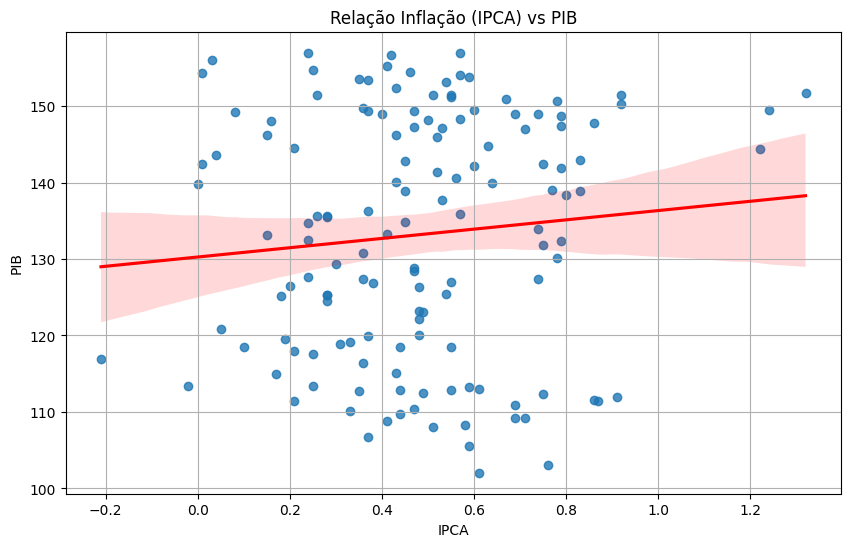

In [ ]:
# Unir as bases pelo campo ANO_MES
df_merged = pd.merge(df_pib, df_ipca[['ANO_MES', 'IPCA']], on='ANO_MES', how='inner').dropna()

# Exibir Matriz de Correlação focada no PIB
print("--- Correlação com o PIB ---")
display(df_merged[['PIB', 'IPCA', 'BRP', 'BRL']].corr()['PIB'])

# Gráfico de dispersão com linha de tendência
plt.figure(figsize=(10, 6))
sns.regplot(data=df_merged, x='IPCA', y='PIB', line_kws={"color": "red"})
plt.title('Relação Inflação (IPCA) vs PIB')
plt.grid(True)
plt.show()

# **4: Modelo Preditivo (Machine Learning)**

In [ ]:
# Definir variáveis preditoras (X) e alvo (y)
# Usamos PIB anterior, Inflação e Tráfego de Caminhões
X = df_merged[['PIBi1', 'IPCA', 'BRP']]
y = df_merged['PIB']

# Divisão temporal (80% para treino e 20% para teste/validação)
div = int(len(X) * 0.8)
X_treino, X_teste = X.iloc[:div], X.iloc[div:]
y_treino, y_teste = y.iloc[:div], y.iloc[div:]

# Criar e treinar a Regressão Linear
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Realizar as previsões
previsoes = modelo.predict(X_teste)
print("Treinamento concluído com sucesso.")

Treinamento concluído com sucesso.


# **5: Avaliação de Resultados e Acurácia**

Erro Médio Absoluto (MAE): 2.1197
R² Score (Precisão Estatística): 0.3006
Acurácia do Modelo (100-MAPE): 98.60%

--- Pesos das Variáveis no PIB ---


,Impacto
PIBi1,0.605877
IPCA,-1.184371
BRP,0.348671


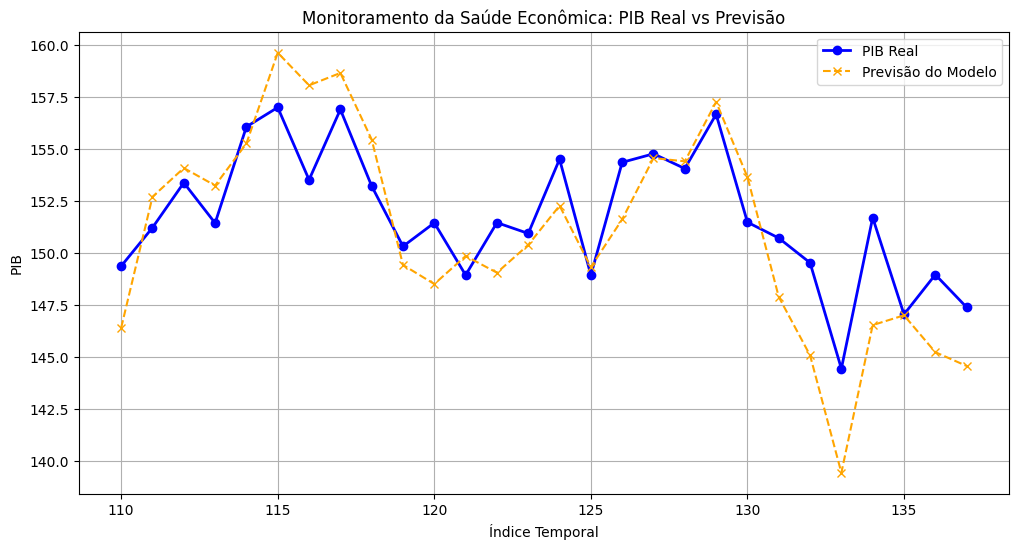

In [ ]:
# 1. Métricas de Erro e Precisão
mae = mean_absolute_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes)
mape = np.mean(np.abs((y_teste - previsoes) / y_teste)) * 100

print(f"Erro Médio Absoluto (MAE): {mae:.4f}")
print(f"R² Score (Precisão Estatística): {r2:.4f}")
print(f"Acurácia do Modelo (100-MAPE): {100 - mape:.2f}%")

# 2. Impacto das Variáveis (Pesos do Modelo)
importancia = pd.DataFrame(modelo.coef_, X.columns, columns=['Impacto'])
print("\n--- Pesos das Variáveis no PIB ---")
display(importancia)

# 3. Gráfico Final de Validação (Real vs Previsão)
plt.figure(figsize=(12, 6))
plt.plot(y_teste.index, y_teste.values, label='PIB Real', color='blue', linewidth=2, marker='o')
plt.plot(y_teste.index, previsoes, label='Previsão do Modelo', color='orange', linestyle='--', marker='x')
plt.title('Monitoramento da Saúde Econômica: PIB Real vs Previsão')
plt.xlabel('Índice Temporal')
plt.ylabel('PIB')
plt.legend()
plt.grid(True)
plt.show()